In [104]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [105]:
from fem import (
    # Core
    Node, Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # Elements
    CST,
    # Units
    kgf, tf, kg, g, cm, m,
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)

In [106]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [107]:
# General model parameters
L = 5000 
H = 500  
B = 300
lc = 100
output_path = os.getcwd()
mesh_name = 'calibrated_beam'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [108]:
# Create a new GMSH model
gmsh.initialize()
gmsh.model.add(mesh_name)

# Corner points
p1 = gmsh.model.geo.addPoint(0,   0, 0, lc)
p2 = gmsh.model.geo.addPoint(L,   0, 0, lc)
p3 = gmsh.model.geo.addPoint(L,   H, 0, lc)
p4 = gmsh.model.geo.addPoint(0,   H, 0, lc)

# Mid points (bottom and top)
p5 = gmsh.model.geo.addPoint(L/2, 0, 0, lc)
p6 = gmsh.model.geo.addPoint(L/2, H, 0, lc)

# Lines
l1 = gmsh.model.geo.addLine(p1, p5)  # Bottom left
l2 = gmsh.model.geo.addLine(p5, p2)  # Bottom right
l3 = gmsh.model.geo.addLine(p2, p3)  # Right side
l4 = gmsh.model.geo.addLine(p3, p6)  # Top right
l5 = gmsh.model.geo.addLine(p6, p4)  # Top left
l6 = gmsh.model.geo.addLine(p4, p1)  # Left side
l7 = gmsh.model.geo.addLine(p5, p6)  # Center vertical

# Surfaces
c1 = gmsh.model.geo.addCurveLoop([l1,  l7, l5, l6])  # Left half
s1 = gmsh.model.geo.addPlaneSurface([c1])

c2 = gmsh.model.geo.addCurveLoop([l2, l3, l4, -l7])  # Right half
s2 = gmsh.model.geo.addPlaneSurface([c2])

gmsh.model.geo.synchronize()

# Physical groups
gmsh.model.addPhysicalGroup(2, [s1, s2], 201)
gmsh.model.setPhysicalName(2, 201, "Beam")

gmsh.model.addPhysicalGroup(0, [p1], 101)
gmsh.model.setPhysicalName(0, 101, "Support_left")

gmsh.model.addPhysicalGroup(0, [p2], 102)
gmsh.model.setPhysicalName(0, 102, "Support_right")

gmsh.model.addPhysicalGroup(0, [p6], 50)
gmsh.model.setPhysicalName(0, 50, "Load")

gmsh.model.geo.synchronize()


In [109]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [110]:
# Define material
fc=210
fc_21 = Material(name='fc_21',
                 E=13500*fc**0.5*kgf/cm**2,
                 nu=0.20,
                 rho= 2400*kg/m**3*g*0)

# Define membrane section
ConcreteBeam = Membrane(name='ConcreteBeam',
                        thickness=300,
                        material=fc_21)

# Map physical group IDs to sections
section_dictionary = {201: ConcreteBeam}

# Define distributed load magnitude
Pload = 10*tf

load_dictionary = {
    50:  {'value': Pload, 'direction': '-y'},   
}

# Define boundary conditions (restraints)
restrain_dictionary = {101: ['r', 'r'],
                       102: ['f', 'r']}


In [111]:
# read mesh — node_map and system_nDof auto-generated
mesh = GMSHtools(output_file)

  MESH SUMMARY

  === NODES ===  (364 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         0.0000         0.0000         0.0000
       2      5000.0000         0.0000         0.0000
       3      5000.0000       500.0000         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (4 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      50      0   'Load'
     101      0   'Support_left'
     102      0   'Support_right'
     201      2   'Beam'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (4 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      50      0       15          1            1  

In [112]:

nDoF = globalParameters['nDoF']
nDIM = globalParameters['nDIM']

# Nodes
all_tags     = sorted(mesh.nodes.keys())
tag_to_index = {tag: i for i, tag in enumerate(all_tags)}

mesh.node_map = {}
for tag in all_tags:
    i      = tag_to_index[tag]
    coords = list(mesh.nodes[tag][:nDIM])
    node   = Node(name=int(tag), coordinates=coords)
    node.idx = np.array([nDoF * i + j for j in range(nDoF)])
    mesh.node_map[tag] = node

mesh.system_nDof = len(all_tags) * nDoF


In [113]:

# --- Dirichlet — restraints ---
for phys_id, condition in restrain_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    for conn in mesh.elements[phys_id]['connectivity']:
        for tag in conn:
            if tag in mesh.node_map:
                mesh.node_map[tag].set_restrain(condition)


In [114]:
# --- Neumann — nodal load dim=0 ---
for phys_id, load_spec in load_dictionary.items():
    pg = mesh.physical_groups.get(phys_id)
    if pg is None or pg.dim != 0:
        continue
    
    # direction vector — manual
    value     = load_spec['value']
    direction = load_spec['direction']
    
    if   direction == 'x':  d = np.array([ 1.,  0.])
    elif direction == '-x': d = np.array([-1.,  0.])
    elif direction == 'y':  d = np.array([ 0.,  1.])
    elif direction == '-y': d = np.array([ 0., -1.])
    
    for tag in pg.nodes:
        if tag in mesh.node_map:
            mesh.node_map[tag].set_nodal_load(value * d)

In [115]:

# Initialize nodes and apply Dirichlet (restraints) and Neumann (nodal loads) boundary conditions.
# mesh.apply_boundary_conditions(restrain_dictionary, load_dictionary,verbose=True)

In [116]:
mesh.node_map

{1: Node 1 at [0. 0.],
 2: Node 2 at [5000.    0.],
 3: Node 3 at [5000.  500.],
 4: Node 4 at [  0. 500.],
 5: Node 5 at [2500.    0.],
 6: Node 6 at [2500.  500.],
 7: Node 7 at [100.   0.],
 8: Node 8 at [200.   0.],
 9: Node 9 at [300.   0.],
 10: Node 10 at [400.   0.],
 11: Node 11 at [500.   0.],
 12: Node 12 at [600.   0.],
 13: Node 13 at [700.   0.],
 14: Node 14 at [800.   0.],
 15: Node 15 at [900.   0.],
 16: Node 16 at [1000.    0.],
 17: Node 17 at [1100.    0.],
 18: Node 18 at [1200.    0.],
 19: Node 19 at [1300.    0.],
 20: Node 20 at [1400.    0.],
 21: Node 21 at [1500.    0.],
 22: Node 22 at [1600.    0.],
 23: Node 23 at [1700.    0.],
 24: Node 24 at [1800.    0.],
 25: Node 25 at [1900.    0.],
 26: Node 26 at [2000.    0.],
 27: Node 27 at [2100.    0.],
 28: Node 28 at [2200.    0.],
 29: Node 29 at [2300.    0.],
 30: Node 30 at [2400.    0.],
 31: Node 31 at [2600.    0.],
 32: Node 32 at [2700.    0.],
 33: Node 33 at [2800.    0.],
 34: Node 34 at [2900

In [117]:
# por tag de gmsh
node = mesh.node_map[6]
print(node)

# o ver sus propiedades
node.print_summary()

Node 6 at [2500.  500.]

Node 6
  Coordinates : [2500.  500.]
  DOF indices : [10 11]
  Nodal load  : [     0. -98070.]
  Restraints  : ['f' 'f']




In [118]:
mesh.elements

{50: {'dim': 0,
  'gmsh_type': 15,
  'n_nodes': 1,
  'element_tags': [3],
  'connectivity': [[6]]},
 101: {'dim': 0,
  'gmsh_type': 15,
  'n_nodes': 1,
  'element_tags': [1],
  'connectivity': [[1]]},
 102: {'dim': 0,
  'gmsh_type': 15,
  'n_nodes': 1,
  'element_tags': [2],
  'connectivity': [[2]]},
 201: {'dim': 2,
  'gmsh_type': 2,
  'n_nodes': 3,
  'element_tags': [4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,


In [119]:
mesh.physical_groups["Beam"].elements


{'dim': 2,
 'gmsh_type': 2,
 'n_nodes': 3,
 'element_tags': [4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,


In [120]:
system_nDof = mesh.system_nDof
node_map = mesh.node_map

In [121]:
# --- Build elements ---
elements = []

for phys_id, section in section_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    group = mesh.elements[phys_id]
    for elem_tag, connectivity in zip(group['element_tags'], group['connectivity']):
        node_list = [node_map[tag] for tag in connectivity]
        elem = CST(
            element_tag = elem_tag,
            node_list   = node_list,
            section     = section,
            type        = 'planeStress',
        )
        elements.append(elem)

elements = np.array(elements, dtype=object)

In [122]:
# assemble consistent load vector
F_load = np.zeros(mesh.system_nDof)
for node in mesh.node_map.values():
    F_load[node.idx] += node.nodalLoad  

for elem in elements:
    F_load[elem.idx] += elem.F_fe_global 
    
F_load[np.abs(F_load) < 1e-4] = 0.0

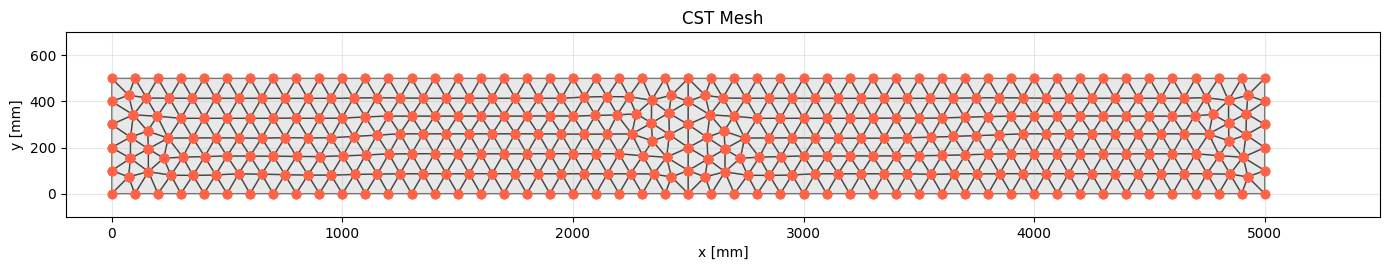

In [123]:
# Plot
fig, ax = plt.subplots(figsize=(14, 4))

for element in elements:
    element.plotGeometry(ax=ax, text=False, nodeLabels=False)

ax.set_xlim(-200, 5500)
ax.set_ylim(-100, 700)
ax.set_aspect('equal')
ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_title('CST Mesh')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [124]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Assembly
K = lil_matrix((system_nDof, system_nDof))
for element in elements:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = F_load.copy()

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in node_map.values()])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, F[free_dofs] - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr = Krf @ uf + Krr @ ur
R  = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [125]:
# Reactions per node
for node in node_map.values():
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' * 50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 1:  Rx=-0.000000  Ry=+49035.000000
Node 2:  Rx=+0.000000  Ry=+49035.000000
----------------------------------------------------------------------------------------------------
Applied X:  +0.0000   Reaction X: -0.0000   Balance: -4.5577e-08
Applied Y:  -98070.0000   Reaction Y: +98070.0000   Balance: 1.4377e-08


In [126]:
print("\n--- ELEMENT FORCES DEBUG ---")
for elem in elements:
    c = elem.get_centroid()
    print(f"elem={elem.element_tag:4d}  centroid=({c[0]:8.3f}, {c[1]:8.3f})")
    print(f"  nodes       = {[node.name for node in elem.nodes]}")
    print(f"  F_fe_body   = {np.round(elem.F_fe_body, 6)}")
    print(f"  F_fe_surface= {np.round(elem.F_fe_surface, 6)}")
    print(f"  F_fe_global = {np.round(elem.F_fe_global, 6)}")


--- ELEMENT FORCES DEBUG ---
elem=   4  centroid=( 147.220,  364.234)
  nodes       = [200, 136, 204]
  F_fe_body   = [ 0. -0.  0. -0.  0. -0.]
  F_fe_surface= [0. 0. 0. 0. 0. 0.]
  F_fe_global = [0. 0. 0. 0. 0. 0.]
elem=   5  centroid=(2352.754,  135.811)
  nodes       = [201, 135, 203]
  F_fe_body   = [ 0. -0.  0. -0.  0. -0.]
  F_fe_surface= [0. 0. 0. 0. 0. 0.]
  F_fe_global = [0. 0. 0. 0. 0. 0.]
elem=   6  centroid=(2318.677,  352.678)
  nodes       = [206, 202, 237]
  F_fe_body   = [ 0. -0.  0. -0.  0. -0.]
  F_fe_surface= [0. 0. 0. 0. 0. 0.]
  F_fe_global = [0. 0. 0. 0. 0. 0.]
elem=   7  centroid=(2365.660,  353.815)
  nodes       = [187, 202, 206]
  F_fe_body   = [ 0. -0.  0. -0.  0. -0.]
  F_fe_surface= [0. 0. 0. 0. 0. 0.]
  F_fe_global = [0. 0. 0. 0. 0. 0.]
elem=   8  centroid=( 180.867,  147.974)
  nodes       = [207, 189, 236]
  F_fe_body   = [ 0. -0.  0. -0.  0. -0.]
  F_fe_surface= [0. 0. 0. 0. 0. 0.]
  F_fe_global = [0. 0. 0. 0. 0. 0.]
elem=   9  centroid=( 132.755,  147

In [127]:
loaded_node_tag = 6

print(f"\n--- ELEMENTS AROUND LOADED NODE {loaded_node_tag} ---")
for elem in elements:
    elem_node_tags = [node.name for node in elem.nodes]
    if loaded_node_tag in elem_node_tags:
        c = elem.get_centroid()
        print(f"elem={elem.element_tag:4d}  centroid=({c[0]:9.3f}, {c[1]:9.3f})")
        print(f"  nodes       = {elem_node_tags}")
        print(f"  F_fe_body   = {np.round(elem.F_fe_body, 4)}")
        print(f"  F_fe_surface= {np.round(elem.F_fe_surface, 4)}")
        print(f"  F_fe_global = {np.round(elem.F_fe_global, 4)}")


--- ELEMENTS AROUND LOADED NODE 6 ---
elem= 211  centroid=( 2475.598,   442.265)
  nodes       = [114, 6, 232]
  F_fe_body   = [ 0. -0.  0. -0.  0. -0.]
  F_fe_surface= [0. 0. 0. 0. 0. 0.]
  F_fe_global = [0. 0. 0. 0. 0. 0.]
elem= 212  centroid=( 2442.265,   475.598)
  nodes       = [6, 83, 232]
  F_fe_body   = [ 0. -0.  0. -0.  0. -0.]
  F_fe_surface= [0. 0. 0. 0. 0. 0.]
  F_fe_global = [0. 0. 0. 0. 0. 0.]
elem= 518  centroid=( 2524.402,   442.265)
  nodes       = [6, 114, 360]
  F_fe_body   = [ 0. -0.  0. -0.  0. -0.]
  F_fe_surface= [0. 0. 0. 0. 0. 0.]
  F_fe_global = [0. 0. 0. 0. 0. 0.]
elem= 519  centroid=( 2557.735,   475.598)
  nodes       = [82, 6, 360]
  F_fe_body   = [ 0. -0.  0. -0.  0. -0.]
  F_fe_surface= [0. 0. 0. 0. 0. 0.]
  F_fe_global = [0. 0. 0. 0. 0. 0.]


## Information for GMSH

In [128]:
n_nodes    = len(node_map)
n_elements = len(elements)

# Prepare displacement, force and reaction arrays (3D format for Gmsh)
u_3d = np.zeros((n_nodes, 3))
F_3d = np.zeros((n_nodes, 3))
R_3d = np.zeros((n_nodes, 3))

for i, node in enumerate(node_map.values()):
    u_3d[i, 0] = u[node.idx[0]]
    u_3d[i, 1] = u[node.idx[1]]
    F_3d[i, 0] = F[node.idx[0]]
    F_3d[i, 1] = F[node.idx[1]]
    R_3d[i, 0] = R[node.idx[0]]
    R_3d[i, 1] = R[node.idx[1]]

# Node tags for Gmsh
node_tags = np.array([node.name for node in node_map.values()])

# Stress, strain and Von Mises
sigma_gmsh             = np.zeros((n_elements, 3))
epsilon_gmsh           = np.zeros((n_elements, 3))
sigma_principal_gmsh   = np.zeros((n_elements, 2))
epsilon_principal_gmsh = np.zeros((n_elements, 2))
von_mises_gmsh         = np.zeros(n_elements)
element_tags_list      = []

for i, element in enumerate(elements):
    results = element.get_results(u)
    sigma   = results['stress'].flatten()
    epsilon = results['strain'].flatten()

    sigma_gmsh[i, :]             = sigma
    epsilon_gmsh[i, :]           = epsilon
    sigma_principal_gmsh[i, :]   = results['principal_stress'].flatten()
    epsilon_principal_gmsh[i, :] = results['principal_strain'].flatten()

    sxx, syy, sxy     = sigma
    von_mises_gmsh[i] = np.sqrt(sxx**2 - sxx*syy + syy**2)
    element_tags_list.append(element.element_tag)

In [129]:
# VISUALIZE RESULTS IN GMSH
gmsh.initialize()
gmsh.open(output_file)

# --- Displacements ---
view_disp = gmsh.view.add("Displacements")
gmsh.view.addHomogeneousModelData(
    tag           = view_disp,
    step          = 0,
    time          = 0,
    modelName     = gmsh.model.getCurrent(),
    dataType      = "NodeData",
    numComponents = -1,
    tags          = node_tags,
    data          = u_3d.reshape(-1)
)
gmsh.view.option.setNumber(view_disp, "VectorType",         5)
gmsh.view.option.setNumber(view_disp, "DisplacementFactor", 10)
gmsh.view.option.setNumber(view_disp,  "Visible", 0)

# --- Applied Loads ---
view_loads = gmsh.view.add("Applied Loads")
gmsh.view.addHomogeneousModelData(
    tag           = view_loads,
    step          = 0,
    time          = 0,
    modelName     = gmsh.model.getCurrent(),
    dataType      = "NodeData",
    numComponents = -1,
    tags          = node_tags,
    data          = F_3d.reshape(-1)
)
gmsh.view.option.setNumber(view_loads, "ArrowSizeMax", 60)
gmsh.view.option.setNumber(view_loads, "ArrowSizeMin", 20)
gmsh.view.option.setNumber(view_loads, "GlyphLocation", 2)
gmsh.view.option.setNumber(view_loads,  "Visible", 0)

# --- Reactions ---
view_reac = gmsh.view.add("Reactions")
gmsh.view.addHomogeneousModelData(
    tag           = view_reac,
    step          = 0,
    time          = 0,
    modelName     = gmsh.model.getCurrent(),
    dataType      = "NodeData",
    numComponents = -1,
    tags          = node_tags,
    data          = R_3d.reshape(-1)
)
gmsh.view.option.setNumber(view_reac,  "Visible", 0)
gmsh.view.option.setNumber(view_reac, "GlyphLocation", 2)


In [130]:
# --- Sxx Nodal Averaged (manual) ---
tag_to_conn = {}
for group in mesh.elements.values():
    for tag, conn in zip(group['element_tags'], group['connectivity']):
        tag_to_conn[tag] = conn

all_node_tags = list(mesh.nodes.keys())
node_idx      = {tag: i for i, tag in enumerate(all_node_tags)}
n_nodes_total = len(all_node_tags)

sxx_nodal = np.zeros(n_nodes_total)
count     = np.zeros(n_nodes_total)

for elem_tag, sxx in zip(element_tags_list, sigma_gmsh[:, 0]):
    if elem_tag not in tag_to_conn:
        continue
    for tag in tag_to_conn[elem_tag]:
        if tag in node_idx:
            idx          = node_idx[tag]
            sxx_nodal[idx] += sxx
            count[idx]     += 1

count[count == 0] = 1
sxx_nodal /= count

In [131]:
# --- Stress Sxx ---
view_sxx = gmsh.view.add("Stress Sxx")
gmsh.view.addHomogeneousModelData(
    tag           = view_sxx,
    step          = 0,
    time          = 0,
    modelName     = gmsh.model.getCurrent(),
    dataType      = "ElementData",
    numComponents = -1,
    tags          = element_tags_list,
    data          = sigma_gmsh[:, 0].reshape(-1)
)
gmsh.view.option.setNumber(view_sxx, "Visible", 0)

# --- Sxx Nodal Averaged ---
view_sxx_avg = gmsh.view.add("Sxx Nodal Averaged")
gmsh.view.addHomogeneousModelData(
    tag           = view_sxx_avg,
    step          = 0,
    time          = 0,
    modelName     = gmsh.model.getCurrent(),
    dataType      = "NodeData",
    numComponents = -1,
    tags          = node_tags,
    data          = sxx_nodal.reshape(-1)
)
gmsh.view.option.setNumber(view_sxx_avg, "Visible", 0)

gmsh.fltk.run()
gmsh.finalize()